<a href="https://colab.research.google.com/github/aiden-dm/CSCI-4170/blob/main/CSCI_4170_Homework_5_Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Projects in AI and ML - Homework 5**
##**Aiden Drover-Mattinen**

# Task 2

For this part of the homework, I chose to work with the Fashion MNIST dataset. Like the original MNIST dataset, it consists of 28x28 grayscale images, but instead of handwritten digits, it contains images of clothing items.

Given my limited access to computing resources, I opted for this dataset because it is computationally inexpensive, allowing me to focus on understanding the implementation of VAEs and GANs without heavy processing demands. Additionally, the Fashion MNIST images are more diverse and visually interesting compared to handwritten digits, making it a more engaging dataset to work with.

## Part 1: Variational Encoder (VAE)

### Prepping the dataset

The first step in implementing the Variational Autoencoder (VAE) is preprocessing the test data. I loaded the images from the dataset and normalized their pixel intensity values to a range of 0 to 1, which helps improve training stability and performance.

In [2]:
import tensorflow as tf
import pandas as pd
import os
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
(train_images, _), (test_images, _) = tf.keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
def preprocess_images(images):
  images = images.reshape((images.shape[0], 28, 28, 1)) / 255.
  return np.where(images > .5, 1.0, 0.0).astype('float32')

train_images = preprocess_images(train_images)
test_images = preprocess_images(test_images)

I also defined the sizes of the training and test sets and set the batch size to 32 to ensure efficient training and optimization.

In [ ]:
train_size = 60000
batch_size = 32
test_size = 10000

In [ ]:
train_dataset = (tf.data.Dataset.from_tensor_slices(train_images)
                 .shuffle(train_size).batch(batch_size))
test_dataset = (tf.data.Dataset.from_tensor_slices(test_images)
                .shuffle(test_size).batch(batch_size))

### Creating the model

The next step was to define the model. I closely followed the tutorial provided in the assignment instructions, ensuring proper implementation. Below, I provide a breakdown of each section, explaining its purpose and functionality as I implement it.

In [ ]:
from IPython import display
import glob
import imageio
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
import tensorflow_probability as tfp
import time

The CVAE consists of three main parts: an encoder, a reparameterization trick, and a decoder.

The encoder takes an input image and compresses it into a lower-dimensional representation using two convolutional layers followed by a dense layer. Instead of outputting a single fixed representation, it produces two values: the mean and log variance. These define a probability distribution, allowing the model to learn a more flexible representation of the data.

The reparameterization trick ensures smooth training by sampling from this learned distribution. It takes the mean and log variance, adds some random noise, and generates a latent vector. This step ensures that the model remains differentiable and can be optimized effectively.

The decoder then takes this latent vector and reconstructs the original image. It expands the compressed representation back into an image using transposed convolutional layers, progressively refining the details. The final output is a reconstructed version of the original input.

Additionally, the sample method allows the model to generate new images by decoding randomly sampled latent vectors. This helps the model generalize well and produce realistic outputs based on the learned data distribution.

In [ ]:
class CVAE(tf.keras.Model):
  """Convolutional variational autoencoder."""

  def __init__(self, latent_dim):
    super(CVAE, self).__init__()
    self.latent_dim = latent_dim
    self.encoder = tf.keras.Sequential(
        [
            tf.keras.layers.InputLayer(input_shape=(28, 28, 1)),
            tf.keras.layers.Conv2D(
                filters=32, kernel_size=3, strides=(2, 2), activation='relu'),
            tf.keras.layers.Conv2D(
                filters=64, kernel_size=3, strides=(2, 2), activation='relu'),
            tf.keras.layers.Flatten(),
            # No activation
            tf.keras.layers.Dense(latent_dim + latent_dim),
        ]
    )

    self.decoder = tf.keras.Sequential(
        [
            tf.keras.layers.InputLayer(input_shape=(latent_dim,)),
            tf.keras.layers.Dense(units=7*7*32, activation=tf.nn.relu),
            tf.keras.layers.Reshape(target_shape=(7, 7, 32)),
            tf.keras.layers.Conv2DTranspose(
                filters=64, kernel_size=3, strides=2, padding='same',
                activation='relu'),
            tf.keras.layers.Conv2DTranspose(
                filters=32, kernel_size=3, strides=2, padding='same',
                activation='relu'),
            # No activation
            tf.keras.layers.Conv2DTranspose(
                filters=1, kernel_size=3, strides=1, padding='same'),
        ]
    )

  @tf.function
  def sample(self, eps=None):
    if eps is None:
      eps = tf.random.normal(shape=(100, self.latent_dim))
    return self.decode(eps, apply_sigmoid=True)

  def encode(self, x):
    mean, logvar = tf.split(self.encoder(x), num_or_size_splits=2, axis=1)
    return mean, logvar

  def reparameterize(self, mean, logvar):
    eps = tf.random.normal(shape=mean.shape)
    return eps * tf.exp(logvar * .5) + mean

  def decode(self, z, apply_sigmoid=False):
    logits = self.decoder(z)
    if apply_sigmoid:
      probs = tf.sigmoid(logits)
      return probs
    return logits

This part of the code defines the optimizer, loss function, and training step for the CVAE.

First, the Adam optimizer is used with a small learning rate (1e-4).

The log_normal_pdf function calculates the probability of a given latent vector under a normal distribution. This is used to compute how well the latent space aligns with a standard normal distribution, which helps the VAE learn meaningful representations.

The compute_loss function calculates the total loss for the model. It does this in three steps:

* The encoder compresses the input and outputs the mean and log variance.
* The reparameterization trick generates a latent vector from these values.
* The decoder reconstructs the image, and the difference between the real and reconstructed images is measured using sigmoid cross-entropy loss.
Additionally, the function computes two probabilistic terms:

logpz: Measures how similar the latent vectors are to a standard normal distribution.
logqz_x: Measures how well the encoder's latent space represents the input data.
The final loss combines these terms to balance reconstruction accuracy and latent space regularization.

The train_step function performs a single training update. It calculates the loss, computes the gradients using tf.GradientTape(), and applies the gradients to update the model's parameters. This function ensures the model learns efficiently over multiple iterations.

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)


def log_normal_pdf(sample, mean, logvar, raxis=1):
  log2pi = tf.math.log(2. * np.pi)
  return tf.reduce_sum(
      -.5 * ((sample - mean) ** 2. * tf.exp(-logvar) + logvar + log2pi),
      axis=raxis)


def compute_loss(model, x):
  mean, logvar = model.encode(x)
  z = model.reparameterize(mean, logvar)
  x_logit = model.decode(z)
  cross_ent = tf.nn.sigmoid_cross_entropy_with_logits(logits=x_logit, labels=x)
  logpx_z = -tf.reduce_sum(cross_ent, axis=[1, 2, 3])
  logpz = log_normal_pdf(z, 0., 0.)
  logqz_x = log_normal_pdf(z, mean, logvar)
  return -tf.reduce_mean(logpx_z + logpz - logqz_x)


@tf.function
def train_step(model, x, optimizer):
  """Executes one training step and returns the loss.

  This function computes the loss and gradients, and uses the latter to
  update the model's parameters.
  """
  with tf.GradientTape() as tape:
    loss = compute_loss(model, x)
  gradients = tape.gradient(loss, model.trainable_variables)
  optimizer.apply_gradients(zip(gradients, model.trainable_variables))

### Training

With the model set up, we can now move on to the training process. First, we need to define key hyperparameters, including the number of epochs, the size of the latent dimension, and the number of images the model will generate.

We also create a random vector, which will serve as input for the decoder during the image generation process. This allows us to visualize how the model learns to generate images over time.

In [ ]:
epochs = 5
latent_dim = 2
num_examples_to_generate = 16

random_vector_for_generation = tf.random.normal(
    shape=[num_examples_to_generate, latent_dim])
model = CVAE(latent_dim)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Next, we define a function to generate and display images as the model trains. This function takes in the model, the current epoch number, and a test sample. It encodes the test sample to obtain the latent representation, reparameterizes it, and then passes it through the decoder to generate images.

The function then arranges the generated images in a 4x4 grid for easy visualization. This allows us to monitor how the model improves over time by comparing the quality of generated images across different epochs.

In [ ]:
def generate_and_save_images(model, epoch, test_sample):
  mean, logvar = model.encode(test_sample)
  z = model.reparameterize(mean, logvar)
  predictions = model.sample(z)
  fig = plt.figure(figsize=(4, 4))

  for i in range(predictions.shape[0]):
    plt.subplot(4, 4, i + 1)
    plt.imshow(predictions[i, :, :, 0], cmap='gray')
    plt.axis('off')

  # tight_layout minimizes the overlap between 2 sub-plots
  #plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))
  plt.show()

Before training, we select a sample from the test set to generate output images. This ensures that we can consistently track the model's progress over time.

Since we need a fixed number of examples, we first check that the batch size is large enough to accommodate them. Then, we take one batch from the test dataset and extract the first num_examples_to_generate images. These images will be used throughout training to visualize how well the model is learning to generate realistic outputs.

In [ ]:
# Pick a sample of the test set for generating output images
assert batch_size >= num_examples_to_generate
for test_batch in test_dataset.take(1):
  test_sample = test_batch[0:num_examples_to_generate, :, :, :]

Before training begins, we visualize the selected test samples to get a sense of the input images.


(16, 28, 28, 1)


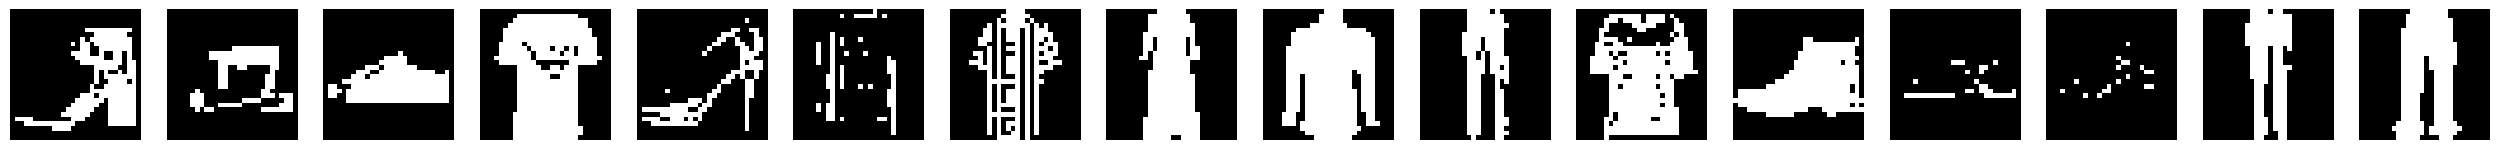

In [ ]:
import matplotlib.pyplot as plt

# Number of images to display
num_images = test_sample.shape[0]

print(test_sample.shape)

# Plot the images
fig, axes = plt.subplots(1, num_images, figsize=(num_images * 2, 2))
for i in range(num_images):
    ax = axes[i] if num_images > 1 else axes
    ax.imshow(test_sample[i, :, :, 0], cmap='gray')  # Assuming grayscale images
    ax.axis('off')

plt.show()

Now it is time to put all of the model pieces together and generate new images!

Epoch: 5, Test set ELBO: -200.5686798095703, time elapse for current epoch: 21.9402596950531


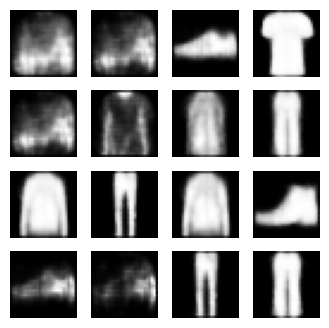

In [ ]:
generate_and_save_images(model, 0, test_sample)

for epoch in range(1, epochs + 1):
  start_time = time.time()
  for train_x in train_dataset:
    train_step(model, train_x, optimizer)
  end_time = time.time()

  loss = tf.keras.metrics.Mean()
  for test_x in test_dataset:
    loss(compute_loss(model, test_x))
  elbo = -loss.result()
  display.clear_output(wait=False)
  print('Epoch: {}, Test set ELBO: {}, time elapse for current epoch: {}'
        .format(epoch, elbo, end_time - start_time))
  generate_and_save_images(model, epoch, test_sample)

## Part 2: Generative Adversarial Network (GAN)

### Preparing the dataset

Next, we follow a similar process to implement a Generative Adversarial Network (GAN). The first step is to load and preprocess the dataset. However, unlike the VAE, we scale the pixel intensities to range from -1 to 1 instead of 0 to 1. This normalization helps stabilize training and improves the performance of the GAN.

In [3]:
(train_images, _), (test_images, _) = tf.keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [4]:
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype('float32')
train_images = (train_images - 127.5) / 127.5  # Normalize the images to [-1, 1]

In [5]:
BUFFER_SIZE = 60000
BATCH_SIZE = 256

In [6]:
# Batch and shuffle the data
train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

### Creating the network

Just like with the CVAE implementation, I closely followed the tutorial provided in the assignment instructions. As I go through each part of the model, I will explain its functionality and how it contributes to the overall GAN architecture.

In [7]:
import glob
import imageio
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
from tensorflow.keras import layers
import time

from IPython import display

The generator model is designed to create realistic-looking images from random noise. The following is a short description of each layer:

* Input Layer: The model takes in a 100-dimensional random vector as input.
* Dense Layer: This layer expands the input into a large feature space (7x7x256) but doesn't use bias.
* Batch Normalization & Leaky ReLU: Helps stabilize training and allows small gradients to flow, preventing dead neurons.
* Reshape Layer: Converts the feature vector into a 3D tensor (7x7x256), setting up for image generation.
* Transposed Convolution Layers: Gradually upscales the image resolution from 7x7 to 28x28 while reducing the number of channels. These layers work like "reverse convolutions," expanding the image instead of shrinking it.
* Activation Function: The final layer uses a tanh activation function, which scales pixel values between -1 and 1, matching the dataset preprocessing.

This model takes random noise and transforms it step by step into a structured image that resembles items from the dataset.

In [8]:
def make_generator_model():
    model = tf.keras.Sequential()
    model.add(layers.Dense(7*7*256, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 256)))
    assert model.output_shape == (None, 7, 7, 256)  # Note: None is the batch size

    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    assert model.output_shape == (None, 7, 7, 128)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    assert model.output_shape == (None, 14, 14, 64)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))
    assert model.output_shape == (None, 28, 28, 1)

    return model

The discriminator model acts as a classifier, determining whether an input image is real (from the dataset) or fake (generated by the generator). I've provided a short description of the functionality of each layer:

* Input Layer: Takes in a 28x28 grayscale image.
* First Convolutional Layer: Applies 64 filters with a 5x5 kernel and a stride of 2 to extract features while reducing the image size.
* Leaky ReLU & Dropout: Leaky ReLU prevents dead neurons, while dropout (0.3) helps prevent overfitting.
* Second Convolutional Layer: Uses 128 filters with similar settings to extract deeper features and further downsample the image.
* Leaky ReLU & Dropout (again): Same purpose as before—helping the model generalize better.
* Flatten Layer: Converts the feature maps into a 1D vector, preparing it for the final classification step.
* Dense Output Layer: Outputs a single value, where higher values indicate the image is real, and lower values suggest it's fake.

This model learns to differentiate between real and generated images, helping the GAN improve over time.

In [9]:
def make_discriminator_model():
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same',
                                     input_shape=[28, 28, 1]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model

This section defines the loss functions for training the GAN. The discriminator loss ensures the discriminator correctly classifies real images as real (output close to 1) and fake images as fake (output close to 0). It does this by computing separate losses for real and fake images using binary cross-entropy and summing them. The generator loss encourages the generator to produce realistic images by making the discriminator classify its outputs as real (output close to 1). Both losses work together in an adversarial setup, where the generator improves at creating realistic images while the discriminator gets better at distinguishing real from fake.

In [10]:
# This method returns a helper function to compute cross entropy loss
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [11]:
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

In [12]:
def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

Here, I'm using the Adam optimizer with a learning rate of 0.0001 to efficiently update the generator and discriminator during training.

In [13]:
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

### Training

With the model created, we can now move onto the training process.

In [14]:
EPOCHS = 50
noise_dim = 100
num_examples_to_generate = 16

# You will reuse this seed overtime (so it's easier)
# to visualize progress in the animated GIF)
seed = tf.random.normal([num_examples_to_generate, noise_dim])

This code initializes the generator and discriminator models and defines the train_step function, which executes one training iteration. During each step, random noise is fed into the generator to create synthetic images, while both real and generated images are passed through the discriminator. The generator and discriminator losses are computed, and their gradients are used to update the models' parameters via backpropagation using the Adam optimizer. This process helps the generator improve at producing realistic images while training the discriminator to distinguish between real and fake samples.

In [15]:
# Initializing the generator and discriminator
generator = make_generator_model()
discriminator = make_discriminator_model()

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
      generated_images = generator(noise, training=True)

      real_output = discriminator(images, training=True)
      fake_output = discriminator(generated_images, training=True)

      gen_loss = generator_loss(fake_output)
      disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


This function generates and displays images using the trained generator model. The training=False argument ensures that layers like batch normalization operate in inference mode. The function takes a set of test inputs, passes them through the generator, and scales the pixel values from the range [-1,1] back to [0,255] for proper visualization. It then arranges the generated images in a 4x4 grid and displays them using Matplotlib.

In [16]:
def generate_and_save_images(model, epoch, test_input):
  # Notice `training` is set to False.
  # This is so all layers run in inference mode (batchnorm).
  predictions = model(test_input, training=False)

  fig = plt.figure(figsize=(4, 4))

  for i in range(predictions.shape[0]):
      plt.subplot(4, 4, i+1)
      plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
      plt.axis('off')

  #plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))
  plt.show()

This function trains the GAN model for a specified number of epochs. In each epoch, it iterates through the dataset, updating the generator and discriminator using train_step(). After each epoch, it clears the previous output and generates sample images using the trained generator to track progress. The training time for each epoch is printed. Finally, after the last epoch, it generates a final set of images for evaluation.

In [17]:
def train(dataset, epochs):
  for epoch in range(epochs):
    start = time.time()

    for image_batch in dataset:
      train_step(image_batch)

    # Produce images for the GIF as you go
    display.clear_output(wait=True)
    generate_and_save_images(generator,
                             epoch + 1,
                             seed)

    print ('Time for epoch {} is {} sec'.format(epoch + 1, time.time()-start))

  # Generate after the final epoch
  display.clear_output(wait=True)
  generate_and_save_images(generator,
                           epochs,
                           seed)

Finally we can train the model and generate some images!

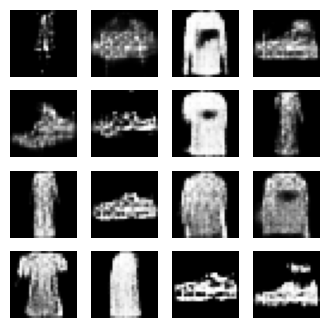

In [18]:
train(train_dataset, EPOCHS)